### **CS 180 Machine Exercise 2:  Multilayer Perceptron**

**Objective**

Train and evaluate a Multilayer Perceptron (MLP) classifier on a real-world dataset using scikit-learn. You will:
- Load and explore the dataset
- Preprocess the data
- Train an MLP classifier
- Evaluate performance with metrics and visualizations


**Step 1: Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

**Step 2: Load and Explore the Dataset**

In [3]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Explore dataset
print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
Shape of X: (569, 30)
Shape of y: (569,)


**Step 3: Split Data into Training and Test Sets**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 4: Preprocess Data**
MLPs are sensitive to feature scaling, so we standardize the dataset.


In [25]:
scaler = StandardScaler()

import copy
X_train_not_scaled = copy.deepcopy(X_train)
X_test_not_scaled = copy.deepcopy(X_test)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(id(X_train_not_scaled), id(X_train))
print(X_train)
print(X_train_not_scaled)

5249840880 5250820560
[[-1.07200079 -0.6584246  -1.0880801  ... -1.35052668 -0.35265805
  -0.54138003]
 [ 1.74874285  0.06650173  1.75115682 ...  1.54991557  0.19107787
  -0.1737386 ]
 [-0.97473376 -0.93112416 -0.99770871 ... -1.70744192 -0.307734
  -1.21303263]
 ...
 [ 0.39844772  1.06867262  0.50751384 ...  1.53492543  0.16164487
   1.23754763]
 [ 0.85331409 -0.0380331   0.9054796  ...  2.10455077  0.31035897
   0.36249578]
 [-0.91179628 -0.82431683 -0.87666079 ... -0.51332734 -0.50756857
   1.30824791]]
[[-1.07200079 -0.6584246  -1.0880801  ... -1.35052668 -0.35265805
  -0.54138003]
 [ 1.74874285  0.06650173  1.75115682 ...  1.54991557  0.19107787
  -0.1737386 ]
 [-0.97473376 -0.93112416 -0.99770871 ... -1.70744192 -0.307734
  -1.21303263]
 ...
 [ 0.39844772  1.06867262  0.50751384 ...  1.53492543  0.16164487
   1.23754763]
 [ 0.85331409 -0.0380331   0.9054796  ...  2.10455077  0.31035897
   0.36249578]
 [-0.91179628 -0.82431683 -0.87666079 ... -0.51332734 -0.50756857
   1.30824791]

**Step 5: Train the MLP Classifier**


In [26]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50),  # one hidden layer
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=50, max_iter=500, random_state=42)

**Step 6: Evaluate the Model** (20 points)
- Evaluate the model using the test set
- Show the classification report
- Display the confusion matrix

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[41  1]
 [ 4 68]]


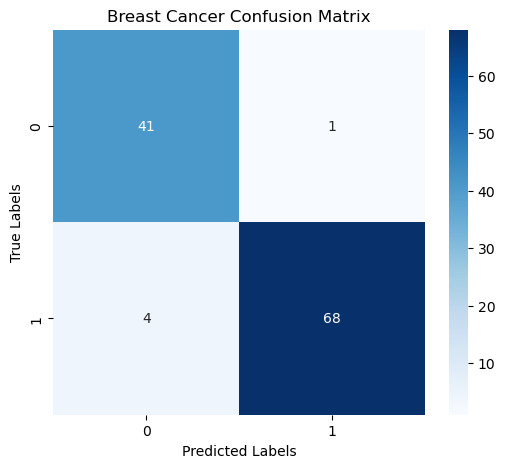

In [27]:
# Write code here

y_pred = mlp.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=mlp.classes_, yticklabels=mlp.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Breast Cancer Confusion Matrix")
plt.show()

def evaluate(model, name):
    y_pred = model.predict(X_test)
    print("{name} Classification Report:".format(name=name))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("{name} Confusion Matrix:".format(name=name))
    print(cm)

    # plt.figure(figsize=(6, 5))
    # sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=mlp.classes_, yticklabels=mlp.classes_)
    # plt.xlabel("Predicted Labels")
    # plt.ylabel("True Labels")
    # plt.title("{name} Breast Cancer Confusion Matrix".format(name=name))
    # plt.show()



**Step 7: Experiment** (40 points)

- Try different hidden_layer_sizes ((100,), (50,50), (100,50,25)).
- Change the activation function ('tanh', 'logistic', 'relu').
- Adjust the learning_rate_init (0.01, 0.001, 0.0001).
- Observe how accuracy changes.


[100] tanh 0.01 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[100] tanh 0.01 Confusion Matrix:
[[41  1]
 [ 1 71]]
[100] tanh 0.01 NOT SCALED Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[100] tanh 0.01 NOT SCALED Confusion Matrix:
[[41  1]
 [ 1 71]]
[100] tanh 0.001 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95  

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[100] logistic 0.0001 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[100] logistic 0.0001 Confusion Matrix:
[[39  3]
 [ 1 71]]
[100] logistic 0.0001 NOT SCALED Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

[100] logistic 0.0001 NOT SCALED Confusion Matrix:
[[39  3]
 [ 1 71]]
[100] relu 0.01 Classification Report:
              precision    recall  f1-score   support

           0       0.9

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[50, 50] logistic 0.0001 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

[50, 50] logistic 0.0001 Confusion Matrix:
[[38  4]
 [ 2 70]]
[50, 50] logistic 0.0001 NOT SCALED Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

[50, 50] logistic 0.0001 NOT SCALED Confusion Matrix:
[[38  4]
 [ 2 70]]
[50, 50] relu 0.01 Classification Report:
              precision    recall  f1-score   support

       

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[50, 50] relu 0.0001 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

[50, 50] relu 0.0001 Confusion Matrix:
[[41  1]
 [ 3 69]]
[50, 50] relu 0.0001 NOT SCALED Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

[50, 50] relu 0.0001 NOT SCALED Confusion Matrix:
[[41  1]
 [ 3 69]]
[100, 50, 25] tanh 0.01 Classification Report:
              precision    recall  f1-score   support

           0      

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[100, 50, 25] logistic 0.0001 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[100, 50, 25] logistic 0.0001 Confusion Matrix:
[[41  1]
 [ 1 71]]
[100, 50, 25] logistic 0.0001 NOT SCALED Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[100, 50, 25] logistic 0.0001 NOT SCALED Confusion Matrix:
[[41  1]
 [ 1 71]]
[100, 50, 25] relu 0.01 Classification Report:
              precision    recall  f1

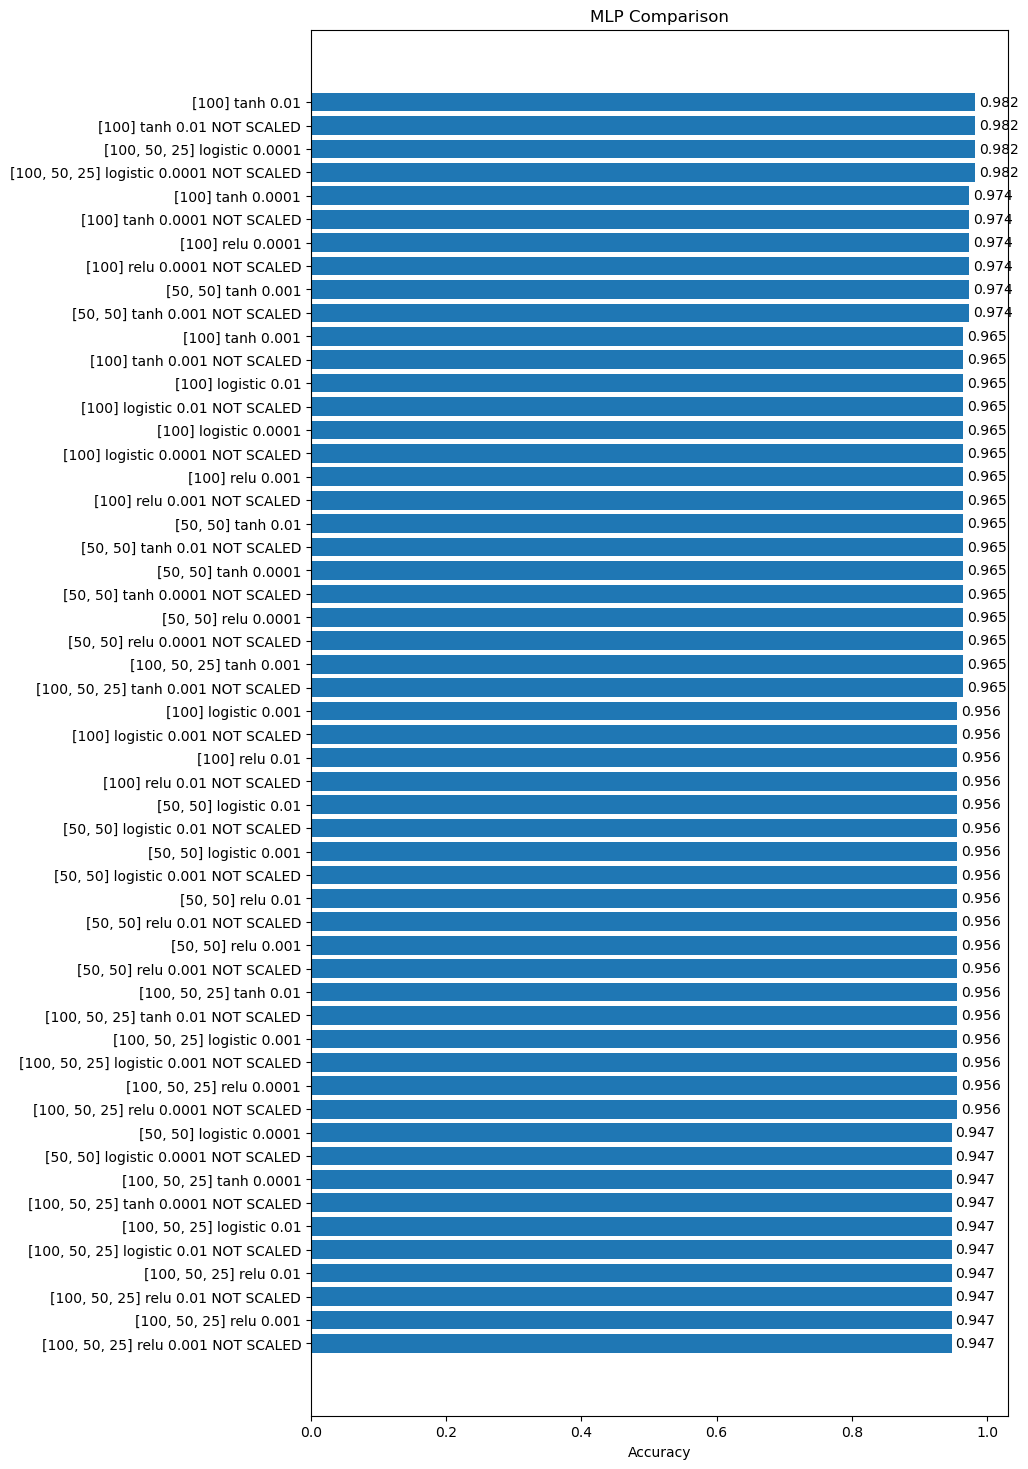

In [28]:
# Write code here
hidden_layers = [
    [100],
    [50, 50],
    [100, 50, 25]
]

activation_functions = [
    "tanh",
    "logistic",
    "relu",
]

learning_rate = [
    0.01,
    0.001,
    0.0001
]

from sklearn.metrics import accuracy_score
results = []

for h in hidden_layers:
    for a in activation_functions:
        for l in learning_rate:
            mlp_experiment = MLPClassifier(
                hidden_layer_sizes=h,
                activation=a,
                solver='adam',
                learning_rate_init=l,
                max_iter=500,
                random_state=42
            )

            mlp_experiment.fit(X_train, y_train)

            mlp_experiment_not_scaled = MLPClassifier(
                hidden_layer_sizes=h,
                activation=a,
                solver='adam',
                learning_rate_init=l,
                max_iter=500,
                random_state=42
            )
            mlp_experiment_not_scaled.fit(X_train_not_scaled, y_train)

            name = "{hidden_layer} {activation_function} {learning_rate}".format(hidden_layer=h, activation_function=a, learning_rate=l)
            evaluate(mlp_experiment, name)
            evaluate(mlp_experiment_not_scaled, name+" NOT SCALED")

            y_pred = mlp_experiment.predict(X_test)
            y_pred_not_scaled = mlp_experiment_not_scaled.predict(X_test_not_scaled)
            acc = accuracy_score(y_test, y_pred)
            acc_not_scaled = accuracy_score(y_test, y_pred_not_scaled)

            results.append((name, acc))
            results.append((name+" NOT SCALED", acc_not_scaled))

results = sorted(results, key=lambda x: x[1], reverse=True)
            
names = [r[0] for r in results]
scores = [r[1] for r in results]

plt.figure(figsize=(9, 18))
plt.barh(names, scores)

plt.xlabel("Accuracy")
plt.title("MLP Comparison")

# Best model on top
plt.gca().invert_yaxis()

# Show values
for i, v in enumerate(scores):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')

plt.show()
        




**Answer the following questions**



**1. How does scaling affect MLP performance?** (10 points)




Answer: Proper scaling in MLPs greatly improve its performance. There would be a faster convergence, improved accuracy, more stable, and keeps the data similar to each other. This is because MLPs use gradient descent (in our case 'adam') and distance-based calculations where a large difference in inputs would make the resulting model more sensitive. From the data above, we can see that there is not much difference among scaling the data and not scaling the data. This could be from the fact that the original data is already scaled to a small enough range that the model can still handle the small range of data inputs.

**2. Compare results between one hidden layer and multiple hidden layers.** (10 points)



Answer: Using the results above, we can observe that increasing the number of hidden layers does not necessarily mean a more accurate model. A majority of the [100, 50, 25] (3 hidden layers) and [50, 50] (2 hidden layers) have a lower accuracy compared to the rest. Only 2 of the [100] (1 hidden layer) scored an accuracy of 0.956 or lower and comparing it to the other 2 number of hidden layers, they had 12 models which had an accuracy of 0.956 or lower. 2/14 of the lowest have 1 hidden layer, and 12/14 have 2 or more hidden layers. However, a multiple hidden layer model can also score high, as the [100, 50, 25] scored the highest with an accuracy of 0.982, and a single hidden layer also reached an accuracy of 0.982. The combination of activation functions, hidden layers, learning rates, and other hyperparameters play a significant role in the performance of a chosen model. 

**3. Plot the loss curve (e.g. mlp.loss_curve_) of the best performing model and describe what you see.** (20 points)



In [ ]:
# Write code here

Answer:

Observations:

